# Clase 6 · Laboratorio — Regresión y Clasificación sobre Saber 11

**Trabajo en parejas · 90 min.**

En la pre-clase viste todos los modelos funcionando. En este laboratorio los implementarás tú con un target diferente: **predecir si un colegio es OFICIAL o NO OFICIAL** a partir de las características de los estudiantes y sus puntajes.

**Checkpoint del profesor a los 50 min** (después de la Tarea 3).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score, RocCurveDisplay,
                              mean_squared_error, mean_absolute_error, r2_score)
from sklearn.preprocessing import StandardScaler
import warnings; warnings.filterwarnings('ignore')

import os
RUTAS = [r"C:\Users\usuario\Downloads\Laboratorios\Ciencias-de-datos\saber11_muestra_500k.csv",
         "../saber11_muestra_500k.csv",
         "saber11_muestra_500k.csv"]
RUTA = next((r for r in RUTAS if os.path.exists(r)), None)
assert RUTA is not None, "No encontré saber11_muestra_500k.csv; revisa RUTAS"
df = pd.read_csv(RUTA)
df["ESTRATO_NUM"] = pd.to_numeric(df["FAMI_ESTRATOVIVIENDA"].astype(str).str.extract(r"(\d+)")[0], errors="coerce")
df["COLE_NAT_BIN"] = (df["COLE_NATURALEZA"] == "NO OFICIAL").astype(int)

FEATURES = ["PUNT_LECTURA_CRITICA","PUNT_MATEMATICAS","PUNT_C_NATURALES",
            "PUNT_SOCIALES_CIUDADANAS","PUNT_INGLES","ESTRATO_NUM"]

df_m = df[FEATURES + ["PUNT_GLOBAL","COLE_NAT_BIN"]].dropna()
print(f"Filas limpias: {len(df_m):,}")
print(f"Balance COLE_NAT_BIN: {df_m['COLE_NAT_BIN'].value_counts(normalize=True).round(3).to_dict()}")
print("(0=OFICIAL, 1=NO OFICIAL)")

Filas limpias: 500,000
Balance COLE_NAT_BIN: {0: 0.72, 1: 0.28}
(0=OFICIAL, 1=NO OFICIAL)


## Tarea 1 (15 min) — Regresión: predecir PUNT_MATEMATICAS

En la pre-clase predijiste PUNT_GLOBAL. Ahora predice **PUNT_MATEMATICAS** usando PUNT_LECTURA_CRITICA, PUNT_C_NATURALES, PUNT_SOCIALES_CIUDADANAS, PUNT_INGLES y ESTRATO_NUM.

1. Haz el split 80/20 con `random_state=42`.
2. Entrena una Regresión Lineal.
3. Calcula MSE, RMSE, MAE, R².
4. Grafica predicho vs real (scatter).
5. ¿Cuál feature tiene el coeficiente más alto? ¿Tiene sentido?

MSE:  224.77
RMSE: 14.99
MAE:  11.95
R²:   0.0323


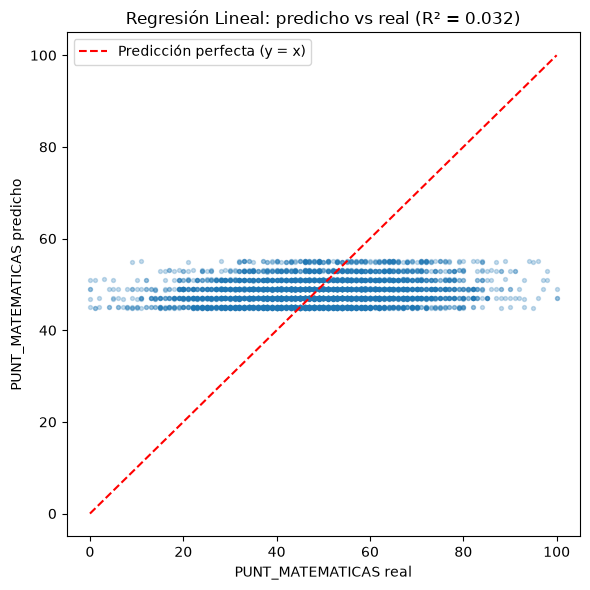


Coeficientes (escala original):
ESTRATO_NUM                 1.9979
PUNT_SOCIALES_CIUDADANAS    0.0033
PUNT_LECTURA_CRITICA        0.0005
PUNT_INGLES                 0.0002
PUNT_C_NATURALES           -0.0006
dtype: float64
Intercepto: 42.8275

Coeficientes estandarizados (comparables entre features):
ESTRATO_NUM                 0.1772
PUNT_SOCIALES_CIUDADANAS    0.0033
PUNT_LECTURA_CRITICA        0.0005
PUNT_INGLES                 0.0002
PUNT_C_NATURALES           -0.0006
dtype: float64


In [4]:
# 1: split 80/20
X_reg = df_m[["PUNT_LECTURA_CRITICA","PUNT_C_NATURALES","PUNT_SOCIALES_CIUDADANAS","PUNT_INGLES","ESTRATO_NUM"]]
y_reg = df_m["PUNT_MATEMATICAS"]
X_tr, X_te, y_tr, y_te = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 2: entrenar Regresión Lineal
lr = LinearRegression()
lr.fit(X_tr, y_tr)

# 3: métricas
y_pred = lr.predict(X_te)
mse  = mean_squared_error(y_te, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_te, y_pred)
r2   = r2_score(y_te, y_pred)
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.4f}")

# 4: scatter predicho vs real (muestra de 5000 puntos para que sea legible)
idx = np.random.RandomState(42).choice(len(y_te), size=min(5000, len(y_te)), replace=False)
plt.figure(figsize=(6, 6))
plt.scatter(y_te.values[idx], y_pred[idx], alpha=0.25, s=8)
lims = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
plt.plot(lims, lims, "r--", label="Predicción perfecta (y = x)")
plt.xlabel("PUNT_MATEMATICAS real")
plt.ylabel("PUNT_MATEMATICAS predicho")
plt.title(f"Regresión Lineal: predicho vs real (R² = {r2:.3f})")
plt.legend()
plt.tight_layout()
plt.show()

# 5: coeficientes
coef = pd.Series(lr.coef_, index=X_reg.columns).sort_values(ascending=False)
print("\nCoeficientes (escala original):")
print(coef.round(4))
print(f"Intercepto: {lr.intercept_:.4f}")

# Coeficientes estandarizados: comparables entre sí (los puntajes van 0-100 y el estrato 1-6)
coef_std = pd.Series(lr.coef_ * X_tr.std().values / y_tr.std(), index=X_reg.columns).sort_values(ascending=False)
print("\nCoeficientes estandarizados (comparables entre features):")
print(coef_std.round(4))

**Interpretación Tarea 1:** el modelo obtuvo RMSE = 14.99, MAE = 11.95 y **R² = 0.0323**: las 5 variables explican solo ~3 % de la varianza de `PUNT_MATEMATICAS`, es decir, predice apenas mejor que usar el promedio.

La feature con el coeficiente más alto es **`ESTRATO_NUM` (≈ 2.00 puntos por cada nivel de estrato; estandarizado 0.177)**. Los puntajes de Lectura Crítica, Naturales, Sociales e Inglés tienen coeficientes prácticamente cero (|coef| < 0.004).

¿Tiene sentido? El efecto del estrato sí es plausible (mayor nivel socioeconómico se asocia con mejor desempeño). Lo que **no** es esperable es que los puntajes de las otras áreas no aporten nada: en datos reales de Saber 11 suelen estar fuertemente correlacionados con Matemáticas. Esto indica que, en esta muestra, los puntajes casi no están relacionados entre sí, y por eso el R² es tan bajo. Conviene verificarlo con `df[FEATURES].corr()`.

## Tarea 2 (20 min) — Clasificar OFICIAL vs NO OFICIAL

Target: `COLE_NAT_BIN` (0=OFICIAL, 1=NO OFICIAL).

1. Haz el split 80/20 estratificado (`stratify=y_clf`).
2. Escala con `StandardScaler` (necesario para KNN y SVM).
3. Entrena los 4 modelos: Regresión Logística, KNN (k=5), SVM (kernel lineal sobre 20k filas), Árbol de Decisión (max_depth=5).
4. Para cada uno: calcula Accuracy, Precision, Recall, F1, AUC.
5. Muestra la matriz de confusión de Regresión Logística.

                     Accuracy  Precision  Recall      F1     AUC
Modelo                                                          
Regresión Logística    0.7198     0.0000  0.0000  0.0000  0.4981
KNN (k=5)              0.6592     0.2781  0.1357  0.1824  0.5004
SVM (lineal)           0.7198     0.0000  0.0000  0.0000  0.4995
Árbol (depth=5)        0.7198     0.3333  0.0002  0.0005  0.5013

Baseline (predecir siempre la clase mayoritaria): 0.7198


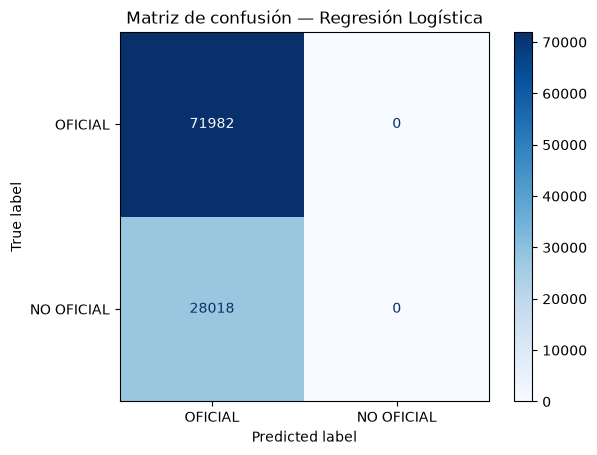

In [5]:
X_clf = df_m[FEATURES]
y_clf = df_m["COLE_NAT_BIN"]

# 1: split estratificado
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# 2: escalar
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr_c)
X_te_sc  = scaler.transform(X_te_c)

# 3-4: entrenar 4 modelos y calcular métricas
resultados = []
preds, scores = {}, {}   # se reutilizan en la Tarea 3

def evaluar(nombre, y_true, y_pred, y_score):
    preds[nombre], scores[nombre] = y_pred, y_score
    resultados.append({
        "Modelo": nombre,
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall":    recall_score(y_true, y_pred),
        "F1":        f1_score(y_true, y_pred),
        "AUC":       roc_auc_score(y_true, y_score),
    })

# Regresión Logística
logreg = LogisticRegression(max_iter=500, random_state=42)
logreg.fit(X_tr_sc, y_tr_c)
evaluar("Regresión Logística", y_te_c, logreg.predict(X_te_sc), logreg.predict_proba(X_te_sc)[:, 1])

# KNN k=5
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_tr_sc, y_tr_c)
evaluar("KNN (k=5)", y_te_c, knn.predict(X_te_sc), knn.predict_proba(X_te_sc)[:, 1])

# SVM lineal (sobre 20000 filas de train)
rng = np.random.RandomState(42)
idx_svm = rng.choice(len(X_tr_sc), size=min(20000, len(X_tr_sc)), replace=False)
svm = SVC(kernel="linear", random_state=42)
svm.fit(X_tr_sc[idx_svm], y_tr_c.values[idx_svm])
evaluar("SVM (lineal)", y_te_c, svm.predict(X_te_sc), svm.decision_function(X_te_sc))

# Árbol de Decisión
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_tr_sc, y_tr_c)
evaluar("Árbol (depth=5)", y_te_c, tree.predict(X_te_sc), tree.predict_proba(X_te_sc)[:, 1])

# 5: imprimir tabla y matriz de confusión
df_res = pd.DataFrame(resultados).set_index("Modelo").round(4)
print(df_res)

baseline = max(y_te_c.mean(), 1 - y_te_c.mean())
print(f"\nBaseline (predecir siempre la clase mayoritaria): {baseline:.4f}")

cm = confusion_matrix(y_te_c, preds["Regresión Logística"])
ConfusionMatrixDisplay(cm, display_labels=["OFICIAL", "NO OFICIAL"]).plot(cmap="Blues")
plt.title("Matriz de confusión — Regresión Logística")
plt.show()

## Tarea 3 (15 min) — Comparación formal

1. Grafica las 4 matrices de confusión en un `plt.subplots(2,2)`.
2. Grafica las 4 curvas ROC en un mismo eje.
3. ¿Cuál modelo recomendarías para detectar colegios NO OFICIALES? Justifica usando las métricas (no solo accuracy).
4. El desbalance del dataset (70/30) ¿afectó los resultados? ¿Cómo lo notas en las métricas?

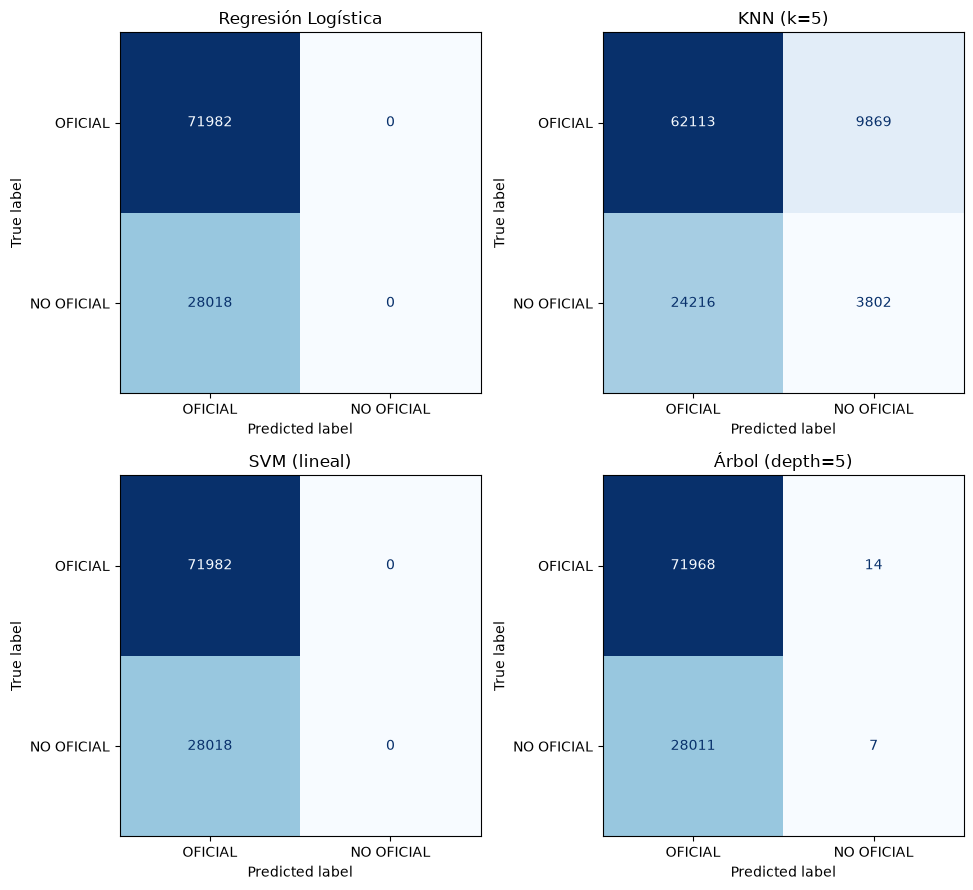

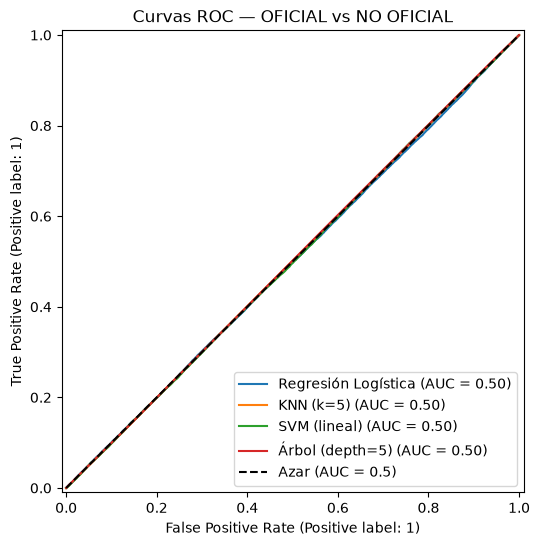

In [6]:
nombres = list(preds.keys())

# 1: 4 matrices de confusión
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, nombre in zip(axes.ravel(), nombres):
    cm = confusion_matrix(y_te_c, preds[nombre])
    ConfusionMatrixDisplay(cm, display_labels=["OFICIAL", "NO OFICIAL"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nombre)
plt.tight_layout()
plt.show()

# 2: 4 curvas ROC en un mismo eje
fig, ax = plt.subplots(figsize=(7, 6))
for nombre in nombres:
    RocCurveDisplay.from_predictions(y_te_c, scores[nombre], name=nombre, ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Azar (AUC = 0.5)")
ax.set_title("Curvas ROC — OFICIAL vs NO OFICIAL")
ax.legend(loc="lower right")
plt.show()

**Modelo recomendado y justificación:**

Para detectar colegios NO OFICIALES (clase positiva) importa el **Recall** de esa clase, sin perder del todo la Precision (F1) y la capacidad de ordenar (AUC). Resultados de la Tarea 2:

| Modelo | Accuracy | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| Regresión Logística | 0.7198 | 0.0000 | 0.0000 | 0.0000 | 0.4981 |
| KNN (k=5) | 0.6592 | 0.2781 | 0.1357 | 0.1824 | 0.5004 |
| SVM (lineal) | 0.7198 | 0.0000 | 0.0000 | 0.0000 | 0.4995 |
| Árbol (depth=5) | 0.7198 | 0.3333 | 0.0002 | 0.0005 | 0.5013 |

De los cuatro, el único que detecta una fracción apreciable de colegios NO OFICIALES es **KNN** (Recall 0.136, F1 0.182), así que sería el menos malo para ese objetivo. Pero hay que ser honestos: **ningún modelo es realmente útil**. Todos tienen AUC ≈ 0.50 (equivale a adivinar al azar) y ninguno supera el accuracy del baseline (0.7198); KNN incluso queda por debajo (0.659). La Regresión Logística y la SVM predicen siempre OFICIAL (Precision y Recall = 0), y su accuracy es idéntico al baseline. La conclusión es que estas 6 variables (puntajes y estrato) **no contienen señal suficiente** para distinguir el tipo de colegio en esta muestra.

**¿El desbalance afectó?**

Sí. La muestra es 72 % OFICIAL / 28 % NO OFICIAL. Se nota en que la Regresión Logística, la SVM y el Árbol obtienen **exactamente el accuracy del baseline (0.7198)** porque colapsan a predecir la clase mayoritaria, con Recall ≈ 0 para NO OFICIAL. El accuracy parece aceptable, pero oculta que la clase de interés no se detecta, por eso hay que mirar Recall, F1 y AUC. Podría mitigarse con `class_weight="balanced"`, bajando el umbral de decisión o con sobre/submuestreo (SMOTE); aun así, con AUC ≈ 0.50 el problema principal es la falta de señal en las variables, no solo el desbalance.

## ⏸ Checkpoint del profesor (10 min)

Discutimos:
- ¿Qué modelo tuvo mejor Recall para NO OFICIAL? ¿Por qué importa?
- Si el 70% de colegios son OFICIALES, predecir siempre OFICIAL daría Accuracy = 70%. ¿Qué obtuvieron sus modelos? ¿Superaron ese baseline?
- ¿Por qué la curva ROC del modelo perfecto sería un ángulo recto en la esquina superior izquierda?

**Respuestas al checkpoint:**

- **Mejor Recall para NO OFICIAL:** KNN (0.136); los demás están en ≈ 0. Importa porque el Recall mide cuántos colegios NO OFICIALES reales logramos encontrar; un modelo con Recall 0 no cumple el objetivo aunque tenga buen accuracy.
- **Baseline:** predecir siempre OFICIAL da 0.7198. La Regresión Logística, la SVM y el Árbol obtuvieron exactamente 0.7198 (no lo superaron) y KNN quedó en 0.659 (por debajo).
- **ROC del modelo perfecto:** alcanza TPR = 1 con FPR = 0, así que la curva sube verticalmente por el borde izquierdo y luego sigue horizontal por el borde superior (ángulo recto en la esquina superior izquierda, AUC = 1).

## Tarea 4 (15 min) — Overfitting en el Árbol de Decisión

1. Entrena un Árbol con `max_depth` de 1 a 20.
2. Para cada depth: calcula accuracy en TRAIN y en TEST.
3. Grafica ambas curvas.
4. Identifica: ¿a qué depth empieza el overfitting? ¿Cuál es el mejor depth?

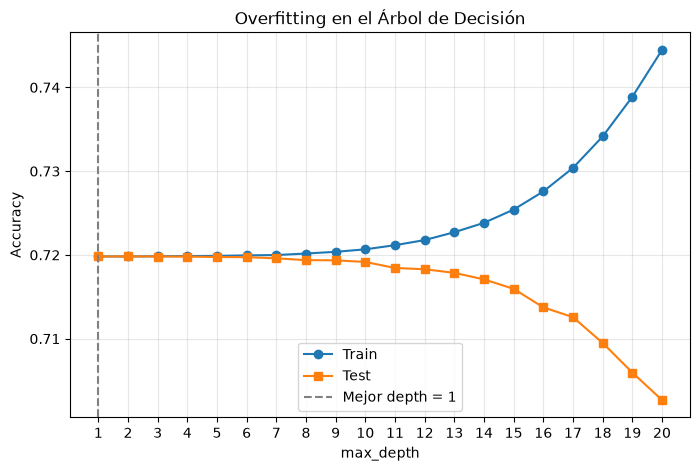

Mejor depth (mayor test accuracy): 1 (test acc = 0.7198)
Brecha train - test por depth:
1    -0.0000
2    -0.0000
3     0.0000
4     0.0001
5     0.0001
6     0.0002
7     0.0004
8     0.0008
9     0.0010
10    0.0015
11    0.0027
12    0.0035
13    0.0048
14    0.0068
15    0.0095
16    0.0138
17    0.0178
18    0.0247
19    0.0329
20    0.0418


In [7]:
# curva overfitting
depths = range(1, 21)
scores_tr, scores_te = [], []
for d in depths:
    arbol = DecisionTreeClassifier(max_depth=d, random_state=42)
    arbol.fit(X_tr_sc, y_tr_c)
    scores_tr.append(arbol.score(X_tr_sc, y_tr_c))
    scores_te.append(arbol.score(X_te_sc, y_te_c))

# graficar
best_d = list(depths)[int(np.argmax(scores_te))]
plt.figure(figsize=(8, 5))
plt.plot(depths, scores_tr, "o-", label="Train")
plt.plot(depths, scores_te, "s-", label="Test")
plt.axvline(best_d, color="gray", linestyle="--", label=f"Mejor depth = {best_d}")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Overfitting en el Árbol de Decisión")
plt.xticks(list(depths))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Mejor depth (mayor test accuracy): {best_d} (test acc = {max(scores_te):.4f})")
gap = np.array(scores_tr) - np.array(scores_te)
print("Brecha train - test por depth:")
print(pd.Series(gap, index=list(depths)).round(4).to_string())

**Interpretación Tarea 4:** la accuracy en *train* sube a medida que crece `max_depth`, mientras que en *test* nunca supera el baseline de 0.7198. La brecha train–test es casi cero hasta depth ≈ 7 (0.0004) y luego crece de forma sostenida: 0.0027 en depth 11, 0.0095 en depth 15 y 0.0418 en depth 20. Es decir, **el overfitting empieza alrededor de depth 8–11**, donde el árbol empieza a memorizar ruido sin ganar nada en test.

El **mejor depth según test accuracy es 1** (0.7198): un árbol de un solo corte equivale a predecir siempre OFICIAL. Esto confirma que las features no aportan información útil para esta tarea; los árboles más profundos solo aumentan la complejidad sin mejorar el desempeño en datos nuevos.

## Tarea 5 (15 min) — Primer modelo sobre el dataset del P2/3

1. Carga el dataset limpio de tu proyecto (`datos_limpios.parquet` si existe, o el CSV original).
2. Define X (features) e y (variable objetivo del P2/3).
3. Haz el split 80/20.
4. Entrena UN modelo (el que consideres más adecuado para tu tipo de problema).
5. Reporta las métricas principales.

Este es tu **modelo baseline** para el P2/3. Los siguientes modelos los entrenarás en casa.

In [15]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

ruta = r"C:\Users\usuario\Downloads\Laboratorios\Ciencias-de-datos\siniestralidad_2016_2024.csv"
d = pd.read_csv(ruta, sep=";", encoding="latin-1", na_values=["."])
print(d.shape)
print(d.columns.tolist())

# Variable objetivo
TARGET = "Tipo confirmado"
d = d.dropna(subset=[TARGET])
print(d[TARGET].value_counts(normalize=True).round(3))

# Features (se descartan Código, Dirección y las columnas duplicadas
# "Tipo confirmado.1" y "Tipo clase de accidente", porque revelan la respuesta)
col_veh = d.columns[9]   # columna de tipo de vehículo
fecha = pd.to_datetime(d["Fecha"], dayfirst=True, errors="coerce")
veh = d[col_veh].fillna("").astype(str).str.upper()

X = pd.DataFrame({
    "anio": fecha.dt.year.fillna(-1),
    "mes": fecha.dt.month.fillna(-1),
    "dia_semana": fecha.dt.dayofweek.fillna(-1),
    "num_vehiculos": pd.to_numeric(d["Numero vehículos"], errors="coerce").fillna(0),
    "es_moto": veh.str.contains("MOTOCICLETA").astype(int),
    "es_auto": veh.str.contains("AUTOMOVIL").astype(int),
})
X = X.join(pd.get_dummies(d["Medio de reporte"], prefix="medio"))
y = d[TARGET]

# Split 80/20
X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Modelo baseline
modelo = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
modelo.fit(X_tr_p, y_tr_p)
yp = modelo.predict(X_te_p)

# Métricas
print("Tipo: Clasificación | Modelo: Random Forest Classifier")
print(f"Accuracy:          {accuracy_score(y_te_p, yp):.4f}")
print(f"Precision (macro): {precision_score(y_te_p, yp, average='macro'):.4f}")
print(f"Recall (macro):    {recall_score(y_te_p, yp, average='macro'):.4f}")
print(f"F1 (macro):        {f1_score(y_te_p, yp, average='macro'):.4f}")
print(classification_report(y_te_p, yp))

(371003, 10)
['Código', 'Fecha', 'Tipo confirmado', 'Dirección reporte', 'Tipo clase de accidente', 'Tipo clase de accidente.1', 'Tipo confirmado.1', 'Medio de reporte', 'Numero vehículos', 'Tipo de vehículos implicados']
Tipo confirmado
Negativo                   0.663
Solo daños                 0.199
Con lesionado              0.128
Con fallecido              0.008
Con fallecido (Foraneo)    0.001
Solo Daños                 0.001
Name: proportion, dtype: float64
Tipo: Clasificación | Modelo: Random Forest Classifier
Accuracy:          0.7612
Precision (macro): 0.4082
Recall (macro):    0.3532
F1 (macro):        0.3675
                         precision    recall  f1-score   support

          Con fallecido       0.23      0.07      0.11       581
Con fallecido (Foraneo)       0.16      0.05      0.08        91
          Con lesionado       0.52      0.44      0.47      9500
               Negativo       0.85      0.87      0.86     49222
             Solo Daños       0.09      0.05  

**Tipo de problema de mi proyecto:** Clasificación multiclase

**Variable objetivo:** `Tipo confirmado` (gravedad del siniestro: Negativo, Solo daños, Con lesionado, Con fallecido)

**Modelo elegido como baseline:** Random Forest Classifier (100 árboles, `random_state=42`), con split 80/20 estratificado

**Métricas obtenidas:** Accuracy = 0.7612 (baseline de predecir siempre "Negativo" = 0.663), Precision macro = 0.4082, Recall macro = 0.3532, F1 macro = 0.3675.

**Lectura de resultados:** el modelo supera el baseline y funciona bien en "Negativo" (F1 0.86) y "Solo daños" (F1 0.62), regular en "Con lesionado" (F1 0.47) y mal en las clases raras ("Con fallecido" F1 0.11) por el desbalance (< 1 % de los datos). Por eso las métricas macro son bajas aunque el accuracy sea alto.

**Mejoras para los siguientes modelos:** unificar etiquetas duplicadas del target ("Solo Daños" = "Solo daños"; "Con fallecido (Foraneo)" = "Con fallecido"), usar `class_weight="balanced"` y agregar variables como hora, comuna o tipo de accidente.

## Entrega

Guarda este notebook completado.
**Nombre:** `02_laboratorio_apellido1_apellido2.ipynb`
**Sube a:** Moodle → Clase 6 → Laboratorio.